# Symulacja: ile CO₂ oszczędzają wspólne dojazdy do jednego oddziału

**Pytania:**
1. O ile procent spada emisja z dojazdów, gdy pracownicy oddziału jeżdżą razem według reguł naszej aplikacji?
2. Ile to w liczbach bezwzględnych dla oddziału (t CO₂/rok, litry, zł, miejsca parkingowe)?
3. Które założenia najbardziej zmieniają wynik?

Notebook jest powtarzalny: dane wejściowe leżą w `data/` (skrypty pobierające w `analysis/`), losowania mają stały seed.

## 1. Metodologia

### Dane prawdziwe

| co | źródło | plik |
|---|---|---|
| rozkład aut (marka, model, paliwo) w Warszawie | CEPiK, pełny zrzut mazowieckiego, stan 17.04.2022, osobowe z rocznika ≥ 2010 (patrz `cepik_flota_warszawa.ipynb`) | `data/cepik/rozklad_aut_warszawa_2010plus.csv` |
| CO₂ i spalanie każdego modelu | EEA, „CO2 emissions from new passenger cars”, średnie homologacyjne 2010–2025 | j.w. |
| ludność dzielnic Warszawy | GUS BDL, zmienna 72305 „ludność ogółem”, 2025 | `data/geo/warszawa_dzielnice.json` |
| granice dzielnic | OpenStreetMap (Nominatim) | j.w. |
| lokalizacja oddziału | ul. Domaniewska 39, Mokotów (Służewiec, największe skupisko biur w Warszawie) | parametr |
| ceny paliw | e-petrol.pl, średnie ogólnopolskie z 30.09.2026: Pb95 8,19 zł, ON 9,14 zł, LPG 3,22 zł | parametr |

### Założenia (brak danych, stąd scenariusze w analizie wrażliwości)

| parametr | wartość | uzasadnienie |
|---|---|---|
| liczba pracowników oddziału | 500 | typowy średni oddział; wrażliwość 200–2000 |
| udział dojeżdżających autem | 45% | **założenie**, brak danych dla konkretnej firmy; wrażliwość 30–60% |
| udział w programie (spośród jeżdżących autem) | 30% | **założenie**; wrażliwość 10–50% |
| uczestników jako kierowcy | 40% | **założenie**, reszta szuka przejazdu; wrażliwość 20–60% |
| dni w biurze | 3 z 5 | praca hybrydowa; wrażliwość |
| godzina wyjazdu | ~N(7:45, 30 min), co 5 min | **założenie** |
| zasięg dojścia do przystanku | 500 m | jak domyślny parametr `find_matches` |
| okno czasowe | ±15 min | jak domyślny parametr `find_matches` |
| przystanki kierowcy | co 1 km wzdłuż linii prostej dom → biuro | **założenie**, przybliżenie trasy i deklarowanych przystanków |
| miejsca dla pasażerów | 3 | 5-osobowe auto, wygodnie |
| droga vs linia prosta | × 1,3 | typowy współczynnik krętości sieci drogowej w mieście |
| dni robocze w roku | 225 | ~251 dni roboczych − 26 dni urlopu |
| realne vs homologacyjne zużycie | × 1,0 | ostrożnie; realne w mieście jest zwykle wyższe |

### Model krok po kroku (jeden przebieg)

1. **Domy:** każdy pracownik dostaje dom w dzielnicy losowanej proporcjonalnie do ludności (GUS), w losowym punkcie wewnątrz granic dzielnicy (OSM).
2. **Kto jeździ autem / kto w programie / kto kierowcą:** losowanie z udziałami jak wyżej. Każdy jeżdżący autem dostaje auto z rozkładu CEPiK (z CO₂ i spalaniem z EEA).
3. **Dzień:** każdy uczestnik jest w biurze z prawdopodobieństwem 3/5.
4. **Dopasowanie (reguły `find_matches`):** pasażerowie w losowej kolejności (kto pierwszy, ten lepszy, jak w aplikacji) dostają kierowcę, który ma przystanek ≤ 500 m od ich domu, wyjeżdża w oknie ±15 min i ma wolne miejsce. Spośród pasujących: najbliższy przystanek.
5. **Bilans:** dopasowany pasażer nie jedzie swoim autem → oszczędność = jego dystans dom–biuro × 1,3 × 2 (tam i z powrotem) × CO₂ jego auta. Kierowca nie nadkłada drogi (pasażer dochodzi do przystanku na jego trasie). Niedopasowani jadą sami, jak dotąd.

Przebieg powtarzamy **500 razy** (nowy oddział i nowy dzień za każdym razem) i podajemy średnią oraz przedział 5–95%.

### Ograniczenia

- Pracownicy mieszkają jak cała Warszawa: bez dojeżdżających spoza miasta i bez ewentualnego skupienia blisko biura.
- Trasy i przystanki w linii prostej, nie po ulicach (prawdziwe trasy zbiegają się na arteriach, więc dopasowań byłoby raczej więcej).
- Powrót symetryczny do przyjazdu (× 2).
- Rozkład aut z 2022 r., CO₂ homologacyjne.
- Udział jeżdżących autem i chętnych do programu to założenia, nie dane. Dlatego wynik jest pokazany jako zależny od nich (sekcja 5).

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
pd.set_option("display.width", 140)

P = dict(
    N=500, SHARE_CAR=0.45, PARTICIPATION=0.30, DRIVER_SHARE=0.40, OFFICE_DAYS=3,
    DEP_MEAN_MIN=7 * 60 + 45, DEP_SD_MIN=30, RADIUS_M=500, TIME_WINDOW_MIN=15,
    STOP_SPACING_KM=1.0, SEATS=3, CIRCUITY=1.3, WORKDAYS=225, REAL_FACTOR=1.0,
    OFFICE=(52.1805, 21.0050),  # ul. Domaniewska 39, Mokotów
)
FUEL_PRICE = {"PETROL": 8.19, "PETROL/ELECTRIC": 8.19, "LPG": 3.22, "DIESEL": 9.14, "DIESEL/ELECTRIC": 9.14}  # zł/l, e-petrol 30.09.2026
RUNS = 500

## 2. Dane wejściowe

In [2]:
cars = pd.read_csv(ROOT / "data/cepik/rozklad_aut_warszawa_2010plus.csv")
cars["w"] = cars.aut / cars.aut.sum()
geo = json.loads((ROOT / "data/geo/warszawa_dzielnice.json").read_text())
dz = pd.DataFrame([{"dzielnica": g["dzielnica"], "ludnosc": g["ludnosc"], "rok": g["rok"]} for g in geo])
print(f"auta: {len(cars)} kombinacji, średnie CO₂ ważone flotą: {(cars.co2_g_km * cars.w).sum():.1f} g/km")
print(f"dzielnice: {len(dz)}, ludność {dz.ludnosc.sum():,} (GUS, {dz.rok.max()})")
dz.sort_values("ludnosc", ascending=False).set_index("dzielnica").ludnosc.to_frame().T

auta: 882 kombinacji, średnie CO₂ ważone flotą: 131.4 g/km
dzielnice: 18, ludność 1,866,729 (GUS, 2025)


dzielnica,Mokotów,Praga-Południe,Białołęka,Wola,Ursynów,Bielany,Bemowo,Targówek,Śródmieście,Wawer,Ochota,Ursus,Praga-Północ,Żoliborz,Wilanów,Włochy,Wesoła,Rembertów
ludnosc,228098,186401,163791,149362,148690,129774,129068,122092,94851,90524,77872,72213,58704,58568,53547,51499,26694,24981


pula domów: (100000, 2) | biuro w granicach Mokotowa: True
odległość dom–biuro w linii prostej: mediana 8.6 km, średnia 9.0 km (drogą ×1.3: 11.2 / 11.7 km)


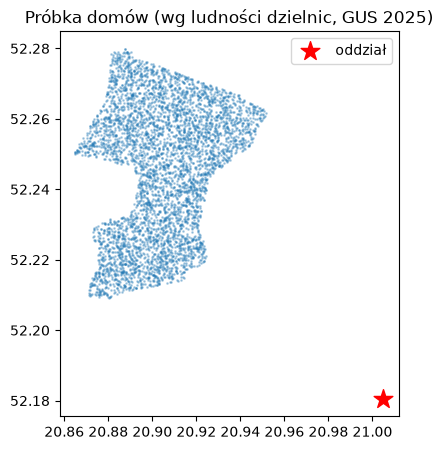

In [3]:
def haversine_m(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    h = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371008.8 * 2 * np.arcsin(np.sqrt(h))

def in_ring(lon, lat, ring):
    """Ray casting, wektorowo dla wielu punktów."""
    x, y = np.asarray(ring)[:, 0], np.asarray(ring)[:, 1]
    inside = np.zeros(len(lon), dtype=bool)
    for i in range(len(x) - 1):
        cond = (y[i] > lat) != (y[i + 1] > lat)
        xint = x[i] + (lat - y[i]) * (x[i + 1] - x[i]) / (y[i + 1] - y[i] + 1e-15)
        inside ^= cond & (lon < xint)
    return inside

def in_polygon(lon, lat, geom):
    polys = [geom["coordinates"]] if geom["type"] == "Polygon" else geom["coordinates"]
    res = np.zeros(len(lon), dtype=bool)
    for rings in polys:
        r = in_ring(lon, lat, rings[0])
        for hole in rings[1:]:
            r &= ~in_ring(lon, lat, hole)
        res |= r
    return res

def sample_in(geom, k, rng):
    pts = np.array([c for ring in ([geom["coordinates"][0]] if geom["type"] == "Polygon" else [p[0] for p in geom["coordinates"]]) for c in ring])
    (lo0, la0), (lo1, la1) = pts.min(0), pts.max(0)
    out = []
    while sum(len(o) for o in out) < k:
        lon, lat = rng.uniform(lo0, lo1, 4 * k), rng.uniform(la0, la1, 4 * k)
        ok = in_polygon(lon, lat, geom)
        out.append(np.c_[lat[ok], lon[ok]])
    return np.vstack(out)[:k]

# pula domów: 100 tys. punktów rozłożonych jak ludność dzielnic (raz, potem losujemy z puli -> szybko)
rng0 = np.random.default_rng(2026)
w_dz = dz.ludnosc / dz.ludnosc.sum()
counts = rng0.multinomial(100_000, w_dz)
HOME_POOL = np.vstack([sample_in(g["geometry"], k, rng0) for g, k in zip(geo, counts)])
mok = next(g for g in geo if g["dzielnica"] == "Mokotów")
print("pula domów:", HOME_POOL.shape, "| biuro w granicach Mokotowa:", in_polygon(np.array([P["OFFICE"][1]]), np.array([P["OFFICE"][0]]), mok["geometry"])[0])
d0 = haversine_m(HOME_POOL[:, 0], HOME_POOL[:, 1], *P["OFFICE"]) / 1000
print(f"odległość dom–biuro w linii prostej: mediana {np.median(d0):.1f} km, średnia {d0.mean():.1f} km "
      f"(drogą ×{P['CIRCUITY']}: {np.median(d0) * P['CIRCUITY']:.1f} / {d0.mean() * P['CIRCUITY']:.1f} km)")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(HOME_POOL[:5000, 1], HOME_POOL[:5000, 0], s=1, alpha=0.3)
ax.scatter([P["OFFICE"][1]], [P["OFFICE"][0]], color="red", marker="*", s=200, label="oddział")
ax.set_title("Próbka domów (wg ludności dzielnic, GUS 2025)"); ax.legend(); ax.set_aspect(1.6); plt.show()

## 3. Model

In [4]:
def make_branch(P, rng):
    n = P["N"]
    home = HOME_POOL[rng.integers(0, len(HOME_POOL), n)]
    car = rng.random(n) < P["SHARE_CAR"]
    part = car & (rng.random(n) < P["PARTICIPATION"])
    driver = part & (rng.random(n) < P["DRIVER_SHARE"])
    dep = np.round(rng.normal(P["DEP_MEAN_MIN"], P["DEP_SD_MIN"], n) / 5) * 5
    ci = rng.choice(len(cars), n, p=cars.w.values)
    straight_km = haversine_m(home[:, 0], home[:, 1], *P["OFFICE"]) / 1000
    return pd.DataFrame(dict(lat=home[:, 0], lon=home[:, 1], car=car, part=part, driver=driver, dep=dep,
                             km=straight_km * P["CIRCUITY"], straight_km=straight_km,
                             fuel=cars.fuel_type.values[ci], co2=cars.co2_g_km.values[ci],
                             l100=cars.l_per_100km.values[ci]))

def driver_stops(drv, P):
    """Przystanki co STOP_SPACING_KM wzdłuż linii prostej dom -> biuro (z domem, bez biura)."""
    rows = []
    for i, r in drv.iterrows():
        k = max(1, int(r.straight_km // P["STOP_SPACING_KM"]))
        t = np.arange(k) / max(k, 1)
        rows.append(np.c_[np.full(k, i), r.lat + t * (P["OFFICE"][0] - r.lat), r.lon + t * (P["OFFICE"][1] - r.lon)])
    return np.vstack(rows) if rows else np.empty((0, 3))

def simulate(P, rng):
    emp = make_branch(P, rng)
    emp["present"] = rng.random(len(emp)) < P["OFFICE_DAYS"] / 5
    day = emp[emp.part & emp.present]
    drv, pax = day[day.driver], day[~day.driver]
    stops = driver_stops(drv, P)
    pos = {i: k for k, i in enumerate(drv.index)}                     # indeks kierowcy -> pozycja w tablicach
    s_drv = np.array([pos[int(i)] for i in stops[:, 0]], dtype=int)  # do którego kierowcy należy przystanek
    s_dep = drv.dep.values[s_drv]
    seats = np.full(len(drv), P["SEATS"])
    matched = []
    order = rng.permutation(len(pax))                                  # kto pierwszy, ten lepszy
    for lat, lon, dep, idx in zip(pax.lat.values[order], pax.lon.values[order], pax.dep.values[order], pax.index[order]):
        if not len(stops):
            break
        dist = haversine_m(lat, lon, stops[:, 1], stops[:, 2])
        ok = (dist <= P["RADIUS_M"]) & (np.abs(s_dep - dep) <= P["TIME_WINDOW_MIN"]) & (seats[s_drv] > 0)
        if ok.any():
            k = s_drv[np.flatnonzero(ok)[np.argmin(dist[ok])]]          # kierowca z najbliższym pasującym przystankiem
            seats[k] -= 1
            matched.append(idx)
    m = pax.loc[matched]
    trip = lambda df: df.km * 2  # tam i z powrotem
    base_part = (trip(day) * day.co2).sum() * P["REAL_FACTOR"]
    base_car = (trip(emp[emp.car & emp.present]) * emp[emp.car & emp.present].co2).sum() * P["REAL_FACTOR"]
    saved = (trip(m) * m.co2).sum() * P["REAL_FACTOR"]
    litres = (trip(m) * m.l100.fillna(0) / 100)
    used = int((seats < P["SEATS"]).sum())
    return dict(
        uczestnicy_w_biurze=len(day), kierowcy=len(drv), pasazerowie=len(pax), dopasowani=len(m),
        proc_dopasowanych=len(m) / len(pax) if len(pax) else np.nan,
        oblozenie=(used + len(m)) / used if used else np.nan,
        oszcz_proc_uczestnicy=saved / base_part if base_part else np.nan,
        oszcz_proc_wszyscy_autem=saved / base_car if base_car else np.nan,
        co2_kg_dzien=saved / 1000, litry_dzien=litres.sum(),
        zl_dzien=(litres * m.fuel.map(FUEL_PRICE).fillna(0)).sum(),
        aut_mniej_dzien=len(m),
    )

def run(P, runs=RUNS, seed=0):
    rng = np.random.default_rng(seed)
    return pd.DataFrame([simulate(P, rng) for _ in range(runs)])

## 4. Wynik dla scenariusza bazowego

In [5]:
res = run(P)
def summary(res, P):
    yr = P["WORKDAYS"]
    rows = {
        "uczestników w biurze (dziennie)": res.uczestnicy_w_biurze,
        "  w tym kierowców": res.kierowcy,
        "  w tym szukających przejazdu": res.pasazerowie,
        "dopasowanych pasażerów (dziennie)": res.dopasowani,
        "% szukających, którzy dostali przejazd": res.proc_dopasowanych * 100,
        "osób w aucie (auta z pasażerami)": res.oblozenie,
        "oszczędność CO₂ wśród uczestników [%]": res.oszcz_proc_uczestnicy * 100,
        "oszczędność CO₂ wszystkich dojazdów autem [%]": res.oszcz_proc_wszyscy_autem * 100,
        "CO₂ zaoszczędzone [t/rok]": res.co2_kg_dzien * yr / 1000,
        "paliwo zaoszczędzone [l/rok]": res.litry_dzien * yr,
        "pieniądze zaoszczędzone [zł/rok]": res.zl_dzien * yr,
        "aut mniej pod biurem (dziennie)": res.aut_mniej_dzien,
    }
    return pd.DataFrame({k: [v.mean(), v.quantile(0.05), v.quantile(0.95)] for k, v in rows.items()},
                        index=["średnio", "5%", "95%"]).T.round(2)
summary(res, P)

,średnio,5%,95%
uczestników w biurze (dziennie),40.30,31.0,50.00
w tym kierowców,16.08,10.0,23.00
w tym szukających przejazdu,24.22,16.0,32.00
dopasowanych pasażerów (dziennie),2.14,0.0,5.00
"% szukających, którzy dostali przejazd",8.81,0.0,20.00
osób w aucie (auta z pasażerami),2.12,2.0,2.67
oszczędność CO₂ wśród uczestników [%],3.46,0.0,8.78
oszczędność CO₂ wszystkich dojazdów autem [%],1.05,0.0,2.76
CO₂ zaoszczędzone [t/rok],0.99,0.0,2.65
paliwo zaoszczędzone [l/rok],412.21,0.0,1101.17


### Model analityczny dla porównania

Jeśli w aucie jedzie średnio *k* osób zamiast każdej osobno, emisja na osobę spada do 1/*k*, czyli oszczędność wynosi **1 − 1/*k***: 2 osoby → 50%, 3 osoby → 67%, 4 osoby → 75%. Symulacja mówi, jakie *k* faktycznie wychodzi przy naszych regułach dopasowania i jaka część uczestników w ogóle znajduje przejazd.

In [6]:
k = res.oblozenie.mean()
print(f"średnie obłożenie aut z pasażerami w symulacji: {k:.2f} osoby -> 1 - 1/k = {(1 - 1 / k) * 100:.0f}% oszczędności w tych autach")

średnie obłożenie aut z pasażerami w symulacji: 2.12 osoby -> 1 - 1/k = 53% oszczędności w tych autach


## 5. Wrażliwość: które założenia zmieniają wynik

Zmieniamy po jednym parametrze, reszta jak w scenariuszu bazowym (200 przebiegów na punkt).

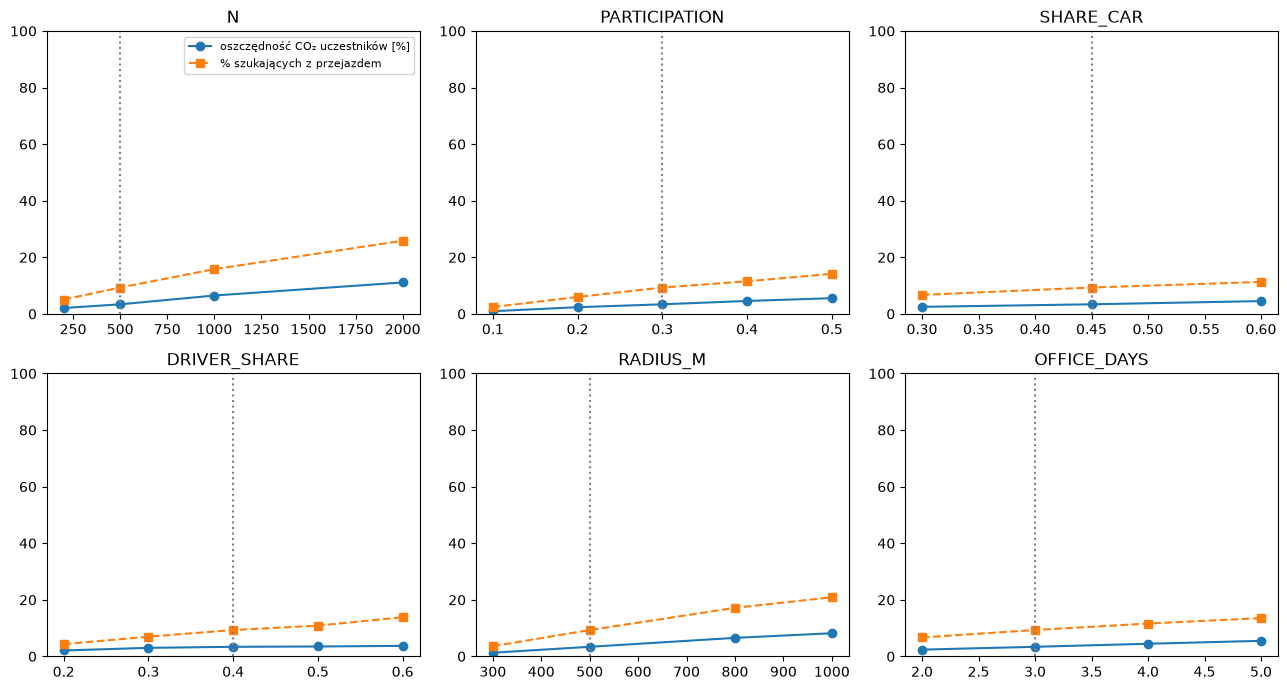

,parametr,wartosc,proc_dopasowanych,oszcz_uczestnicy,oszcz_wszyscy,co2_t_rok
0,N,200.0,5.1,2.1,0.6,0.2
1,N,500.0,9.3,3.4,1.0,1.0
2,N,1000.0,15.8,6.5,2.0,3.7
3,N,2000.0,25.9,11.1,3.3,12.5
4,PARTICIPATION,0.1,2.4,0.9,0.1,0.1
5,PARTICIPATION,0.2,6.0,2.4,0.5,0.5
6,PARTICIPATION,0.3,9.3,3.4,1.0,1.0
7,PARTICIPATION,0.4,11.5,4.6,1.9,1.8
8,PARTICIPATION,0.5,14.2,5.5,2.8,2.6
9,SHARE_CAR,0.3,6.7,2.5,0.8,0.5


In [7]:
GRID = {
    "N": [200, 500, 1000, 2000],
    "PARTICIPATION": [0.1, 0.2, 0.3, 0.4, 0.5],
    "SHARE_CAR": [0.3, 0.45, 0.6],
    "DRIVER_SHARE": [0.2, 0.3, 0.4, 0.5, 0.6],
    "RADIUS_M": [300, 500, 800, 1000],
    "OFFICE_DAYS": [2, 3, 4, 5],
}
sens = []
for name, values in GRID.items():
    for v in values:
        r = run({**P, name: v}, runs=200, seed=1)
        sens.append(dict(parametr=name, wartosc=v, proc_dopasowanych=r.proc_dopasowanych.mean() * 100,
                         oszcz_uczestnicy=r.oszcz_proc_uczestnicy.mean() * 100,
                         oszcz_wszyscy=r.oszcz_proc_wszyscy_autem.mean() * 100,
                         co2_t_rok=r.co2_kg_dzien.mean() * P["WORKDAYS"] / 1000))
sens = pd.DataFrame(sens)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (name, g) in zip(axes.flat, sens.groupby("parametr", sort=False)):
    ax.plot(g.wartosc, g.oszcz_uczestnicy, "o-", label="oszczędność CO₂ uczestników [%]")
    ax.plot(g.wartosc, g.proc_dopasowanych, "s--", label="% szukających z przejazdem")
    ax.axvline(P[name], color="grey", ls=":")
    ax.set_title(name); ax.set_ylim(0, 100)
axes.flat[0].legend(fontsize=8)
plt.tight_layout(); plt.show()
sens.round(1)

## 6. Scenariusz: wspólna pula dzielnicy biurowej

Wrażliwość pokazuje, że wynik zależy głównie od **gęstości** uczestników (liczba osób, udział, zasięg dojścia). Jeden oddział 500 osób to za mało. Służewiec (biuro z naszego scenariusza) to dziesiątki firm w jednym miejscu: gdyby dopasowanie działało w obrębie dzielnicy biurowej zamiast jednego oddziału, pula rośnie o rząd wielkości. Sprawdzamy pule 2–10 tys. pracowników (te same udziały), dla obecnych i elastyczniejszych reguł (dojście 800 m, okno ±30 min). 100 przebiegów na punkt.

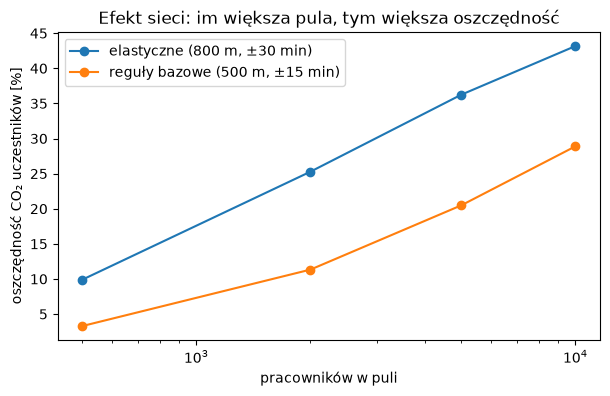

,pracownikow,reguly,proc_dopasowanych,oszcz_uczestnicy,oszcz_wszyscy,oblozenie,co2_t_rok,aut_mniej_dzien
0,500,"reguły bazowe (500 m, ±15 min)",8.5,3.3,1.0,2.1,1.0,2.1
1,500,"elastyczne (800 m, ±30 min)",24.0,9.9,3.1,2.3,2.9,6.0
2,2000,"reguły bazowe (500 m, ±15 min)",25.7,11.3,3.4,2.3,12.8,25.2
3,2000,"elastyczne (800 m, ±30 min)",51.9,25.3,7.6,2.6,28.5,50.9
4,5000,"reguły bazowe (500 m, ±15 min)",43.8,20.5,6.2,2.5,57.8,107.2
5,5000,"elastyczne (800 m, ±30 min)",69.7,36.2,10.9,2.8,102.3,170.5
6,10000,"reguły bazowe (500 m, ±15 min)",58.0,28.9,8.6,2.7,161.4,281.2
7,10000,"elastyczne (800 m, ±30 min)",80.0,43.2,12.9,2.9,241.2,387.5


In [8]:
FLEX = dict(RADIUS_M=800, TIME_WINDOW_MIN=30)
pula = []
for n in [500, 2000, 5000, 10000]:
    for label, extra in [("reguły bazowe (500 m, ±15 min)", {}), ("elastyczne (800 m, ±30 min)", FLEX)]:
        r = run({**P, "N": n, **extra}, runs=100, seed=2)
        pula.append(dict(pracownikow=n, reguly=label, proc_dopasowanych=r.proc_dopasowanych.mean() * 100,
                         oszcz_uczestnicy=r.oszcz_proc_uczestnicy.mean() * 100,
                         oszcz_wszyscy=r.oszcz_proc_wszyscy_autem.mean() * 100,
                         oblozenie=r.oblozenie.mean(), co2_t_rok=r.co2_kg_dzien.mean() * P["WORKDAYS"] / 1000,
                         aut_mniej_dzien=r.aut_mniej_dzien.mean()))
pula = pd.DataFrame(pula)
fig, ax = plt.subplots(figsize=(7, 4))
for label, g in pula.groupby("reguly"):
    ax.plot(g.pracownikow, g.oszcz_uczestnicy, "o-", label=label)
ax.set_xscale("log"); ax.set_xlabel("pracowników w puli"); ax.set_ylabel("oszczędność CO₂ uczestników [%]")
ax.set_title("Efekt sieci: im większa pula, tym większa oszczędność"); ax.legend(); plt.show()
pula.round(1)

## 7. Wnioski

**1. Na poziomie auta teza się potwierdza.** Gdy pasażer znajduje kierowcę, w aucie jedzie średnio 2,1–2,9 osoby, czyli na tych przejazdach jest **53–65% mniej CO₂** (1 − 1/k). Kierowca nie nadkłada drogi, bo pasażer dochodzi do przystanku na jego trasie.

**2. Na poziomie jednego oddziału 500 osób efekt jest mały.** Przy założeniach bazowych przejazd znajduje ok. 9% szukających: −3% CO₂ uczestników, −1% wszystkich dojazdów autem, ok. 1 t CO₂ i 3,5 tys. zł rocznie. Powód: ok. 40 uczestników dziennie rozsianych po całej Warszawie to za mała gęstość, żeby trasy i godziny się pokrywały.

**3. Najmocniejsze dźwignie** (sekcja 5): wielkość puli i udział w programie (efekt sieci), potem zasięg dojścia do przystanku i okno czasowe, potem dni w biurze. Udział kierowców ma mniejsze znaczenie, byle nie spadł poniżej ok. 30%.

**4. Pula całej dzielnicy biurowej zmienia obraz** (sekcja 6). 10 tys. pracowników przy elastycznych regułach (800 m, ±30 min): **80% szukających dostaje przejazd, −43% CO₂ uczestników** (−13% wszystkich dojazdów autem przy 30% udziale), ok. **240 t CO₂ rocznie** i ok. **390 aut mniej pod biurami dziennie**. Przy regułach bazowych: 58% i −29%.

**5. Wnioski dla produktu** (do decyzji zespołu):
- dopasowanie **między firmami w tej samej lokalizacji** (biurowiec, dzielnica biurowa), a nie tylko w obrębie oddziału. Dziś baza i `find_matches` ograniczają się do oddziału;
- domyślnie szersze reguły (np. 800 m, ±30 min);
- ewentualnie dopasowanie do całej trasy kierowcy, a nie tylko zadeklarowanych przystanków.

**6. Jak to mówić na prezentacji:** „Każde wspólne auto to mniej więcej o połowę mniej CO₂ na osobę. Skala rośnie z gęstością: w dzielnicy biurowej z 10 tys. pracowników to ok. 240 t CO₂ rocznie i ok. 390 aut mniej pod biurami każdego dnia.” Zawsze z dopiskiem, że to symulacja na prawdziwej flocie (CEPiK + EEA) i prawdziwej geografii (GUS + OSM), z jawnymi założeniami o zachowaniu ludzi.